In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import warnings
import sys
sys.path.append("A2")
sys.path.append("preprocessing")
import regression_tree as rt
import random_forest as rf
import prediction_evaluation as eval
import grid_search
import parameter_eval
import preprocessing_food_wastage as pre_food_wastage
import preprocessing_college_ranking as pre_college_ranking
import preprocessing_popular_songs as pre_ppl_songs

pd.set_option("display.max_colwidth", None)

# Processing Datasets

In [4]:
warnings.filterwarnings('ignore', category=FutureWarning)

food_waste_df_train, food_waste_df_test = pre_food_wastage.preprocessing_food_wastage()
college_rank_df_train, college_rank_df_test = pre_college_ranking.preprocessing_college_ranking()
popular_songs_features_train, popular_songs_features_test = pre_ppl_songs.preprocessing_popular_songs()

Dataset Food Wastage
Full dataframe: 1782 rows, 11 attributes
Rows containing NA values before preprocessing: 0
Train dataframe: 1188 rows, 11 attributes
Test dataframe: 594 rows, 11 attributes


Dataset University Ranking
Full dataframe: 167 rows, 41 attributes
Rows containing NA values before preprocessing: 160
Train dataframe: 111 rows, 41 attributes
Test dataframe: 56 rows, 41 attributes


Dataset Popular Songs
Full dataframe: 18835 rows, 14 attributes
Rows containing NA values before preprocessing: 0
Train dataframe: 12557 rows, 14 attributes
Test dataframe: 6278 rows, 14 attributes


# Paramater Grid

In [37]:
param_grid = {
    'min_samples_split': range(4,20,4),
    'max_depth': range(1,10,2),
    'split_criterion': ['mse', 'sse']
}


param_grid_scikit = {
    'min_samples_split': range(4,20,2),
    'max_depth': range(1,10,2),
    'criterion': ['squared_error']
}


param_grid_rf = {
    'no_of_estimators': range(10,100,20),
    'split_criterion': ['sse'],
    'max_depth': range(1,10,2),
    'min_samples_split': range(4,13,4),
    'max_features_criterion': ['sqrt', 'log2']
}
param_grid_rf_scikit = {
    'n_estimators': range(10,100,20),
    'criterion': ['squared_error'],
    'max_depth': range(1,10,2),
    'min_samples_split': range(4,13,4),
    'max_features': ['sqrt', 'log2']
}

# Regression Trees

## Food Waste

### Our Implementation

In [38]:
best_tree_food_waste, train_results_food_waste = grid_search.grid_search_cv2(
    food_waste_df_train, "wastage_food_amount", rt.regression_tree, rt.predict_from_tree, param_grid)

train_results_food_waste.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  40 | elapsed:    5.7s remaining:   32.3s
[Parallel(n_jobs=-1)]: Done  15 out of  40 | elapsed:   10.6s remaining:   17.7s
[Parallel(n_jobs=-1)]: Done  24 out of  40 | elapsed:   13.8s remaining:    9.2s
[Parallel(n_jobs=-1)]: Done  33 out of  40 | elapsed:   16.7s remaining:    3.5s
[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:   30.2s finished


,runtime,mean_rmse,mean_mae,Parameters
0,28.508874,3.588023,2.141455,"{'min_samples_split': 4, 'max_depth': 9, 'split_criterion': 'sse'}"
1,18.006769,3.600167,2.389796,"{'min_samples_split': 8, 'max_depth': 7, 'split_criterion': 'sse'}"
2,18.689620,3.604068,2.332517,"{'min_samples_split': 4, 'max_depth': 7, 'split_criterion': 'sse'}"
3,21.601642,3.738945,2.357735,"{'min_samples_split': 8, 'max_depth': 9, 'split_criterion': 'sse'}"
4,13.537699,3.953892,2.827408,"{'min_samples_split': 4, 'max_depth': 5, 'split_criterion': 'sse'}"
5,18.071830,3.956767,2.657784,"{'min_samples_split': 12, 'max_depth': 9, 'split_criterion': 'sse'}"


### Scikitlearn Implementation

In [39]:
train_results_food_waste_scikit, best_tree_scikit_food_waste = grid_search.grid_search_scikit(
    food_waste_df_train, "wastage_food_amount", param_grid_scikit)

train_results_food_waste_scikit.loc[:5,]

Fitting 5 folds for each of 40 candidates, totalling 200 fits
DecisionTreeRegressor(max_depth=9, min_samples_split=14, random_state=1)
Time(s):  0.8044117810204625


,runtime,mean_rmse,mean_mae,Parameters
0,0.804412,3.202585,1.939226,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 14}"
1,0.804412,3.203612,1.914761,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 12}"
2,0.804412,3.204538,1.989038,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 16}"
3,0.804412,3.213652,1.889940,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 10}"
4,0.804412,3.244165,1.879883,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 8}"
5,0.804412,3.262096,2.062978,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 18}"


### Predictions on Test Set

In [40]:
# Our implementaiton
food_waste_predictions_on_test_reg_tree = rt.predict_from_tree(
    best_tree_food_waste, food_waste_df_test)

food_waste_rmse_on_test_reg_tree, food_waste_mae_on_test_reg_tree = eval.measure_predictions(
    food_waste_df_test["wastage_food_amount"], 
    food_waste_predictions_on_test_reg_tree)

print(f"Food waste score on test set using our own implementation. RMSE: {food_waste_rmse_on_test_reg_tree}, MAE: {food_waste_mae_on_test_reg_tree}")


# scikit-learn
food_waste_predictions_on_test_reg_tree_scikit = best_tree_scikit_food_waste.predict(
    food_waste_df_test.loc[:, food_waste_df_test.columns != "wastage_food_amount"])

food_waste_rmse_on_test_reg_tree_scikit, food_waste_mae_on_test_reg_tree_scikit = eval.measure_predictions(
    food_waste_df_test["wastage_food_amount"], 
    food_waste_predictions_on_test_reg_tree_scikit)

print(f"Food waste score on test set using Scikit implementation. RMSE: {food_waste_rmse_on_test_reg_tree_scikit}, MAE: {food_waste_mae_on_test_reg_tree_scikit}")

Food waste score on test set using our own implementation. RMSE: 3.15446446763887, MAE: 1.8145407791952106
Food waste score on test set using Scikit implementation. RMSE: 3.1985216148270506, MAE: 1.8731796309690236


## College Rank

### Our Implementation

In [41]:
best_tree_college_rank, train_results_college_rank = grid_search.grid_search_cv2(
    college_rank_df_train, "2023", rt.regression_tree, rt.predict_from_tree, param_grid)

train_results_college_rank.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  40 | elapsed:    1.0s remaining:    5.9s
[Parallel(n_jobs=-1)]: Done  15 out of  40 | elapsed:    2.4s remaining:    4.0s
[Parallel(n_jobs=-1)]: Done  24 out of  40 | elapsed:    3.1s remaining:    2.0s
[Parallel(n_jobs=-1)]: Done  33 out of  40 | elapsed:    4.3s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:    7.1s finished


,runtime,mean_rmse,mean_mae,Parameters
0,4.253196,9.738025,7.783541,"{'min_samples_split': 4, 'max_depth': 5, 'split_criterion': 'mse'}"
1,6.686174,9.903707,8.021812,"{'min_samples_split': 4, 'max_depth': 9, 'split_criterion': 'sse'}"
2,5.993410,10.038966,7.915640,"{'min_samples_split': 4, 'max_depth': 7, 'split_criterion': 'mse'}"
3,6.096142,10.600316,8.614122,"{'min_samples_split': 4, 'max_depth': 7, 'split_criterion': 'sse'}"
4,3.192702,10.647040,8.785097,"{'min_samples_split': 4, 'max_depth': 3, 'split_criterion': 'sse'}"
5,7.088300,10.764258,8.719875,"{'min_samples_split': 4, 'max_depth': 9, 'split_criterion': 'mse'}"


### Scikit-learn Implementation

In [42]:
train_results_college_rank_scikit, best_tree_scikit_college_rank = grid_search.grid_search_scikit(
    college_rank_df_train, "2023", param_grid_scikit)

train_results_college_rank_scikit.loc[:5,]

Fitting 5 folds for each of 40 candidates, totalling 200 fits
DecisionTreeRegressor(max_depth=5, min_samples_split=8, random_state=1)
Time(s):  0.6947719170711935


,runtime,mean_rmse,mean_mae,Parameters
0,0.694772,9.962908,7.933744,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 8}"
1,0.694772,10.119857,8.261271,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 12}"
2,0.694772,10.159822,8.173889,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 10}"
3,0.694772,10.237771,8.173559,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 8}"
4,0.694772,10.254054,8.169620,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 8}"
5,0.694772,10.319483,8.272593,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 18}"


### Predictions on test set

In [43]:
# Our Implementation
college_rank_predictions_reg_tree = rt.predict_from_tree(
    best_tree_college_rank, 
    college_rank_df_test)

college_rank_rmse_on_test_reg_tree, college_rank_mae_on_test_reg_tree = eval.measure_predictions(
    college_rank_df_test["2023"], 
    college_rank_predictions_reg_tree)

print(f"College Rank scores on test set using our implementation. RMSE: {college_rank_rmse_on_test_reg_tree}, MAE: {college_rank_mae_on_test_reg_tree}")


# scikit_learn
college_rank_predictions_reg_tree_scikit = best_tree_scikit_college_rank.predict(
    college_rank_df_test.loc[:, college_rank_df_test.columns != "2023"])

college_rank_rmse_on_test_reg_tree_scikit, college_rank_mae_on_test_reg_tree_scikit = eval.measure_predictions(
    college_rank_df_test["2023"], 
    college_rank_predictions_reg_tree_scikit)

print(f"College Rank scores on test set using Scikit implementation. RMSE: {college_rank_rmse_on_test_reg_tree_scikit}, MAE: {college_rank_mae_on_test_reg_tree_scikit}")


College Rank scores on test set using our implementation. RMSE: 10.446427310896846, MAE: 8.431396447467876
College Rank scores on test set using Scikit implementation. RMSE: 10.103077791391781, MAE: 8.038446969696968


## Popular Songs

### Our Implementation

In [44]:
best_tree_popular_songs, train_results_popular_songs = grid_search.grid_search_cv2(
    popular_songs_features_train, "song_popularity", rt.regression_tree, rt.predict_from_tree, param_grid)
train_results_popular_songs.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  40 | elapsed:   22.1s remaining:  2.1min
[Parallel(n_jobs=-1)]: Done  15 out of  40 | elapsed:   41.3s remaining:  1.1min
[Parallel(n_jobs=-1)]: Done  24 out of  40 | elapsed:   55.4s remaining:   37.0s
[Parallel(n_jobs=-1)]: Done  33 out of  40 | elapsed:  1.2min remaining:   14.8s
[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:  1.4min finished


,runtime,mean_rmse,mean_mae,Parameters
0,83.641121,21.160975,16.666737,"{'min_samples_split': 8, 'max_depth': 9, 'split_criterion': 'sse'}"
1,61.433988,21.206807,16.798522,"{'min_samples_split': 12, 'max_depth': 7, 'split_criterion': 'sse'}"
2,85.237778,21.214953,16.772709,"{'min_samples_split': 16, 'max_depth': 9, 'split_criterion': 'sse'}"
3,57.076443,21.229848,16.821696,"{'min_samples_split': 8, 'max_depth': 7, 'split_criterion': 'sse'}"
4,50.812081,21.230623,16.872534,"{'min_samples_split': 12, 'max_depth': 5, 'split_criterion': 'sse'}"
5,67.276757,21.255584,16.793905,"{'min_samples_split': 4, 'max_depth': 7, 'split_criterion': 'sse'}"


### Scikitlearn Implementation

In [45]:
train_results_popular_songs_scikit, best_tree_scikit_popular_songs = grid_search.grid_search_scikit(
    popular_songs_features_train, "song_popularity", param_grid_scikit)

train_results_popular_songs_scikit.loc[:5,]

Fitting 5 folds for each of 40 candidates, totalling 200 fits
DecisionTreeRegressor(max_depth=7, min_samples_split=16, random_state=1)
Time(s):  8.400169817963615


,runtime,mean_rmse,mean_mae,Parameters
0,8.40017,21.234650,16.837872,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 16}"
1,8.40017,21.245361,16.846063,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 12}"
2,8.40017,21.245575,16.845303,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 18}"
3,8.40017,21.252407,16.845806,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 6}"
4,8.40017,21.252868,16.849669,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 14}"
5,8.40017,21.255305,16.848190,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 10}"


### Predictions on Test Set

In [46]:
# Our Implementation
popular_songs_predictions_reg_tree = rt.predict_from_tree(
    best_tree_popular_songs, 
    popular_songs_features_test)

popular_songs_rmse_reg_tree, popular_songs_mae_reg_tree = eval.measure_predictions(
    popular_songs_features_test["song_popularity"], 
    popular_songs_predictions_reg_tree)

print(f"Popular Songs scores on test set using our implementation. RMSE:{popular_songs_rmse_reg_tree}, MAE:{popular_songs_mae_reg_tree}")


# scikit_learn
popular_songs_predictions_reg_tree_scikit = best_tree_scikit_popular_songs.predict(
    popular_songs_features_test.loc[:, popular_songs_features_test.columns != "song_popularity"])

popular_songs_rmse_reg_tree_scikit, popular_songs_mae_reg_tree_scikit = eval.measure_predictions(
    popular_songs_features_test["song_popularity"], 
    popular_songs_predictions_reg_tree_scikit)

print(f"Popular Songs scores on test set using Scikit implementation. RMSE{popular_songs_rmse_reg_tree_scikit}, MAE{popular_songs_mae_reg_tree_scikit}")

Popular Songs scores on test set using our implementation. RMSE:20.929219081981884, MAE:16.516791459616286
Popular Songs scores on test set using Scikit implementation. RMSE20.806856423713224, MAE16.500446347275858


# Random Forest

For Random forest, we do not need to use CV, because then we loose the OOB data for each bootstrap. So we do OOB eval instead with the same grid.

## Food Waste

### Our Implementation

In [15]:
best_forest_food_waste, train_results_rf_food_waste = grid_search.grid_search_oob(
    food_waste_df_train, "wastage_food_amount", param_grid_rf)

train_results_rf_food_waste.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:   20.7s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:   27.4s
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:   51.7s
[Parallel(n_jobs=-1)]: Done  87 out of 150 | elapsed:  1.4min remaining:  1.0min
[Parallel(n_jobs=-1)]: Done 103 out of 150 | elapsed:  1.9min remaining:   52.1s
[Parallel(n_jobs=-1)]: Done 119 out of 150 | elapsed:  2.5min remaining:   38.6s
[Parallel(n_jobs=-1)]: Done 135 out of 150 | elapsed:  3.5min remaining:   23.4s
[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed:  4.9min finished


,runtime,mean_rmse,mean_mae,Parameters
0,155.022481,4.319458,3.252234,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 4, 'max_features_criterion': 'sqrt'}"
1,170.965065,4.420795,3.242422,"{'no_of_estimators': 90, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 4, 'max_features_criterion': 'sqrt'}"
2,123.424698,4.540198,3.474478,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 7, 'min_samples_split': 4, 'max_features_criterion': 'log2'}"
3,169.825701,4.548726,3.375137,"{'no_of_estimators': 90, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 4, 'max_features_criterion': 'log2'}"
4,118.919651,4.571226,3.377654,"{'no_of_estimators': 50, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 4, 'max_features_criterion': 'log2'}"
5,75.290216,4.611817,3.316949,"{'no_of_estimators': 30, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 8, 'max_features_criterion': 'log2'}"


### Scikit Implementation

In [22]:
warnings.filterwarnings('ignore', category=UserWarning)
train_results_rf_food_waste_scikit, best_forest_scikit_food_waste = grid_search.grid_search_oob_scikit(
    food_waste_df_train, "wastage_food_amount", param_grid_rf_scikit)

train_results_rf_food_waste_scikit.loc[:5,]

,runtime,mean_rmse,mean_mse,Parameters
0,0.139833,4.229072,17.885047,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 4, 'max_features': 'sqrt'}"
1,0.147058,4.229072,17.885047,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 4, 'max_features': 'log2'}"
2,0.117610,4.233046,17.918678,"{'n_estimators': 70, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 4, 'max_features': 'log2'}"
3,0.107107,4.233046,17.918678,"{'n_estimators': 70, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 4, 'max_features': 'sqrt'}"
4,0.099251,4.271701,18.247433,"{'n_estimators': 50, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 4, 'max_features': 'sqrt'}"
5,0.093482,4.271701,18.247433,"{'n_estimators': 50, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 4, 'max_features': 'log2'}"


### Prediction on Test set

In [23]:
# Our Implementation
food_waste_predictions_rf = rf.predict_from_forest(
    food_waste_df_test, best_forest_food_waste)

food_waste_rmse_rf, food_waste_mae_rf = eval.measure_predictions(
    food_waste_df_test["wastage_food_amount"], 
    food_waste_predictions_rf)

print(f"Food waste scores on test set using Our implementation. RMSE {food_waste_rmse_rf}, MAE {food_waste_mae_rf}")


# scikit-learn
food_waste_predictions_rf_scikit = best_forest_scikit_food_waste.predict(
    food_waste_df_test.loc[:, food_waste_df_test.columns != "wastage_food_amount"])

food_waste_rmse_rf_scikit, food_waste_mae_rf_scikit = eval.measure_predictions(
    food_waste_df_test["wastage_food_amount"], 
    food_waste_predictions_rf_scikit)

print(f"Food waste scores on test set using Scikit implementation. RMSE {food_waste_rmse_rf_scikit}, MAE {food_waste_mae_rf_scikit}")

Food waste scores on test set using Our implementation. RMSE 3.871002934969125, MAE 3.0186603535581393
Food waste scores on test set using Scikit implementation. RMSE 4.12837674229126, MAE 3.198822309707646


## College Rank

### Our Implementation

In [24]:
best_forest_college_rank, train_results_rf_college_rank = grid_search.grid_search_oob(
    college_rank_df_train, "2023", param_grid_rf)

train_results_rf_college_rank.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done  87 out of 150 | elapsed:   17.0s remaining:   12.3s
[Parallel(n_jobs=-1)]: Done 103 out of 150 | elapsed:   20.0s remaining:    9.1s
[Parallel(n_jobs=-1)]: Done 119 out of 150 | elapsed:   27.2s remaining:    7.1s
[Parallel(n_jobs=-1)]: Done 135 out of 150 | elapsed:   32.6s remaining:    3.6s
[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed:   47.1s finished


,runtime,mean_rmse,mean_mae,Parameters
0,22.928297,10.969149,8.460529,"{'no_of_estimators': 50, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 4, 'max_features_criterion': 'sqrt'}"
1,16.264744,11.719278,9.138241,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 7, 'min_samples_split': 8, 'max_features_criterion': 'sqrt'}"
2,22.927817,11.720013,8.872304,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 4, 'max_features_criterion': 'log2'}"
3,22.015809,12.102477,9.146306,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 7, 'min_samples_split': 4, 'max_features_criterion': 'sqrt'}"
4,14.690152,12.183239,8.922654,"{'no_of_estimators': 30, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 4, 'max_features_criterion': 'sqrt'}"
5,14.772252,12.229086,9.593533,"{'no_of_estimators': 90, 'split_criterion': 'sse', 'max_depth': 7, 'min_samples_split': 8, 'max_features_criterion': 'log2'}"


### Scikit Implmentation

In [25]:
train_results_rf_college_rank_scikit, best_forest_scikit_college_rank = grid_search.grid_search_oob_scikit(
    college_rank_df_train, "2023", param_grid_rf_scikit)

train_results_rf_college_rank_scikit.loc[:5,]

,runtime,mean_rmse,mean_mse,Parameters
0,0.025525,10.217991,104.407336,"{'n_estimators': 10, 'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 8, 'max_features': 'sqrt'}"
1,0.024816,10.291469,105.914341,"{'n_estimators': 10, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 8, 'max_features': 'sqrt'}"
2,0.070420,10.526772,110.812924,"{'n_estimators': 50, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 4, 'max_features': 'sqrt'}"
3,0.077214,10.579891,111.934099,"{'n_estimators': 50, 'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 4, 'max_features': 'sqrt'}"
4,0.057212,10.721492,114.950393,"{'n_estimators': 30, 'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 4, 'max_features': 'sqrt'}"
5,0.077227,10.760882,115.796586,"{'n_estimators': 50, 'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 4, 'max_features': 'sqrt'}"


### Predictions on Test Set

In [26]:
# Our Implementation
college_rank_predictions_rf = rf.predict_from_forest(
    college_rank_df_test, 
    best_forest_college_rank)

college_rank_rmse_rf, college_rank_mae_rf = eval.measure_predictions(
    college_rank_df_test["2023"], 
    college_rank_predictions_rf)

print(f"College Rank scores on test set using Our implementation. RMSE {college_rank_rmse_rf}, MAE {college_rank_mae_rf}")


# scikit-learn
college_rank_predictions_rf_scikit = best_forest_scikit_college_rank.predict(
    college_rank_df_test.loc[:, college_rank_df_test.columns != "2023"])

college_rank_rmse_rf_scikit, college_rank_mae_rf_scikit = eval.measure_predictions(
    college_rank_df_test["2023"], 
    college_rank_predictions_rf_scikit)

print(f"College Rank scores on test set using Our implementation. RMSE {college_rank_rmse_rf_scikit}, MAE {college_rank_mae_rf_scikit}")

College Rank scores on test set using Our implementation. RMSE 10.260182467073989, MAE 7.983321686491339
College Rank scores on test set using Our implementation. RMSE 10.56718658349667, MAE 8.202730088285776


## Popular Songs

### Our Implementation

In [30]:
best_forest_popular_songs, train_results_rf_popular_songs = grid_search.grid_search_oob(
    popular_songs_features_train, 
    "song_popularity", 
    param_grid_rf)

train_results_rf_popular_songs.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:   23.0s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done  87 out of 150 | elapsed:  9.3min remaining:  6.7min
[Parallel(n_jobs=-1)]: Done 103 out of 150 | elapsed: 12.5min remaining:  5.7min
[Parallel(n_jobs=-1)]: Done 119 out of 150 | elapsed: 15.6min remaining:  4.1min
[Parallel(n_jobs=-1)]: Done 135 out of 150 | elapsed: 19.4min remaining:  2.2min
[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed: 24.4min finished


,runtime,mean_rmse,mean_mae,Parameters
0,667.109017,20.441398,16.238480,"{'no_of_estimators': 90, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 8, 'max_features_criterion': 'sqrt'}"
1,765.359642,20.464768,16.233115,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 4, 'max_features_criterion': 'sqrt'}"
2,686.144902,20.470538,16.233644,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 12, 'max_features_criterion': 'sqrt'}"
3,713.763322,20.480951,16.268295,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 8, 'max_features_criterion': 'sqrt'}"
4,658.022844,20.489260,16.219858,"{'no_of_estimators': 90, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 12, 'max_features_criterion': 'sqrt'}"
5,760.774564,20.495097,16.245501,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 9, 'min_samples_split': 4, 'max_features_criterion': 'log2'}"


### Scikit Implementation

In [31]:
train_results_rf_popular_songs_scikit, best_forest_scikit_popular_songs = grid_search.grid_search_oob_scikit(
    popular_songs_features_train, 
    "song_popularity", 
    param_grid_rf_scikit)

train_results_rf_popular_songs_scikit.loc[:5,]

,runtime,mean_rmse,mean_mse,Parameters
0,0.244562,20.028123,401.125715,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 4, 'max_features': 'sqrt'}"
1,0.240260,20.028123,401.125715,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 4, 'max_features': 'log2'}"
2,0.203536,20.043587,401.745392,"{'n_estimators': 70, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 4, 'max_features': 'log2'}"
3,0.191432,20.043587,401.745392,"{'n_estimators': 70, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 4, 'max_features': 'sqrt'}"
4,0.237738,20.056756,402.273467,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 8, 'max_features': 'log2'}"
5,0.232050,20.056756,402.273467,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 8, 'max_features': 'sqrt'}"


### Predictions on test set

In [32]:
# Our Implementation
popular_songs_predictions_rf = rf.predict_from_forest(
    popular_songs_features_test, 
    best_forest_popular_songs)

popular_songs_rmse_rf, popular_songs_mae_rf = eval.measure_predictions(
    popular_songs_features_test["song_popularity"], 
    popular_songs_predictions_rf)

print(f"Popular Songs scores on test set using Our implementation. RMSE {popular_songs_rmse_rf}, MAE {popular_songs_mae_rf}")


# scikit-learn
popular_songs_predictions_rf_scikit = best_forest_scikit_popular_songs.predict(
    popular_songs_features_test.loc[:, popular_songs_features_test.columns != "song_popularity"])

popular_songs_rmse_rf_scikit, popular_songs_mae_rf_scikit = eval.measure_predictions(
    popular_songs_features_test["song_popularity"], 
    popular_songs_predictions_rf_scikit)

print(f"Popular Songs scores on test set using Scikit implementation. RMSE{popular_songs_rmse_rf_scikit}, MAE{popular_songs_mae_rf_scikit}")

Popular Songs scores on test set using Our implementation. RMSE 19.84753861121853, MAE 15.735736375646292
Popular Songs scores on test set using Scikit implementation. RMSE19.804345548371206, MAE15.746671926026828


# KNN

## Food Waste

In [48]:
food_waste_knn_model, food_waste_knn_runtime = grid_search.knn(food_waste_df_train, "wastage_food_amount")
food_waste_predictions_on_test_knn_scikit = food_waste_knn_model.predict(food_waste_df_test.loc[:, food_waste_df_test.columns != "wastage_food_amount"])
food_waste_rmse_on_test_knn_scikit, food_waste_mae_on_test_knn_scikit = eval.measure_predictions(food_waste_df_test["wastage_food_amount"], food_waste_predictions_on_test_reg_tree_scikit)

print(f"Food waste score on test set using Scikit KNN implementation. RMSE: {food_waste_rmse_on_test_knn_scikit}, MAE: {food_waste_mae_on_test_knn_scikit}")


food_waste_knn_results = {
    'runtime': food_waste_knn_runtime,
    'test set rmse': food_waste_rmse_on_test_knn_scikit,
    'test set mae': food_waste_mae_on_test_knn_scikit,
    'algorithm': "KNN",
    'dataset': "Food Wastage",
    'implementation': 'Scikit'
}


Food waste score on test set using Scikit KNN implementation. RMSE: 3.1985216148270506, MAE: 1.8731796309690236


## College Rank

In [49]:
college_rank_knn_model, college_rank_knn_runtime = grid_search.knn(college_rank_df_train, "2023")
college_rank_predictions_on_test_knn_scikit = college_rank_knn_model.predict(college_rank_df_test.loc[:, college_rank_df_test.columns != "2023"])
college_rank_rmse_on_test_knn_scikit, college_rank_mae_on_test_knn_scikit = eval.measure_predictions(college_rank_df_test["2023"], college_rank_predictions_on_test_knn_scikit)

print(f"University rank score on test set using Scikit KNN implementation. RMSE: {college_rank_rmse_on_test_knn_scikit}, MAE: {college_rank_mae_on_test_knn_scikit}")


college_rank_knn_results = {
    'runtime': college_rank_knn_runtime,
    'test set rmse': college_rank_rmse_on_test_knn_scikit,
    'test set mae': college_rank_mae_on_test_knn_scikit,
    'algorithm': "KNN",
    'dataset': "University Rank",
    'implementation': 'Scikit'
}


University rank score on test set using Scikit KNN implementation. RMSE: 11.764808297873547, MAE: 8.589285714285714


## Popular Songs

In [50]:
popular_songs_knn_model, popular_songs_knn_runtime = grid_search.knn(popular_songs_features_train, "song_popularity")
popular_songs_predictions_on_test_knn_scikit = popular_songs_knn_model.predict(popular_songs_features_test.loc[:, popular_songs_features_test.columns != "song_popularity"])
popular_songs_rmse_on_test_knn_scikit, popular_songs_mae_on_test_knn_scikit = eval.measure_predictions(popular_songs_features_test["song_popularity"], popular_songs_predictions_on_test_knn_scikit)

print(f"Popular Songs score on test set using Scikit KNN implementation. RMSE: {popular_songs_rmse_on_test_knn_scikit}, MAE: {popular_songs_mae_on_test_knn_scikit}")


popular_songs_knn_results = {
    'runtime': popular_songs_knn_runtime,
    'test set rmse': popular_songs_rmse_on_test_knn_scikit,
    'test set mae': popular_songs_mae_on_test_knn_scikit,
    'algorithm': "KNN",
    'dataset': "Popular Songs",
    'implementation': 'Scikit'
}


Popular Songs score on test set using Scikit KNN implementation. RMSE: 32.05099572331079, MAE: 24.63969417011787


# Hyperparameter Sensitivity Evaluation

## Regression Tree

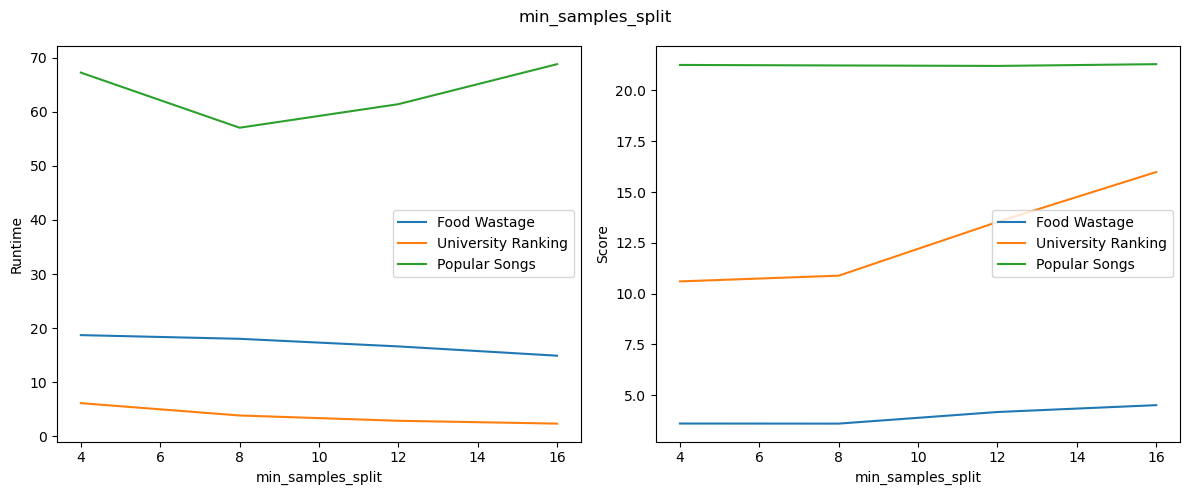

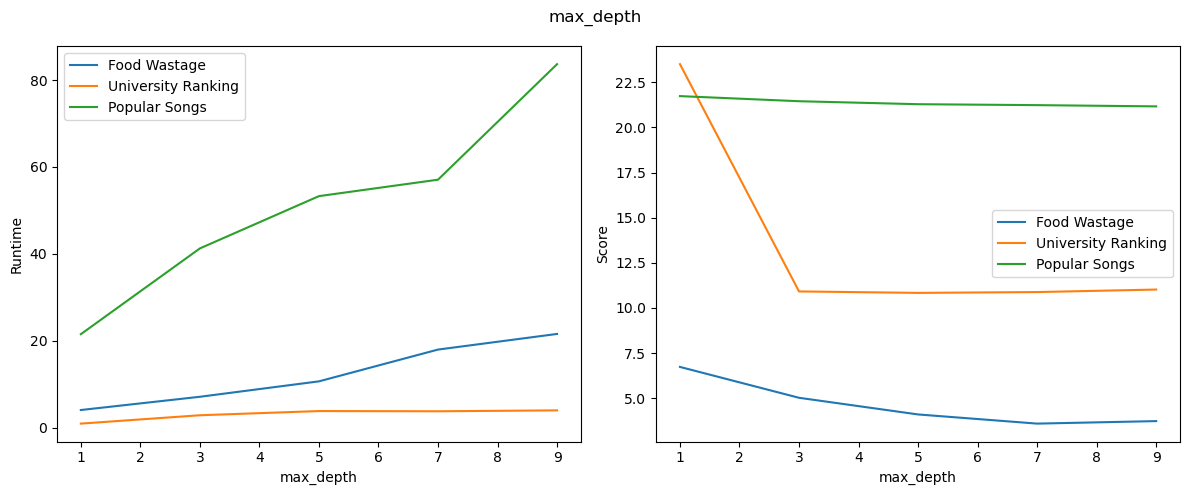

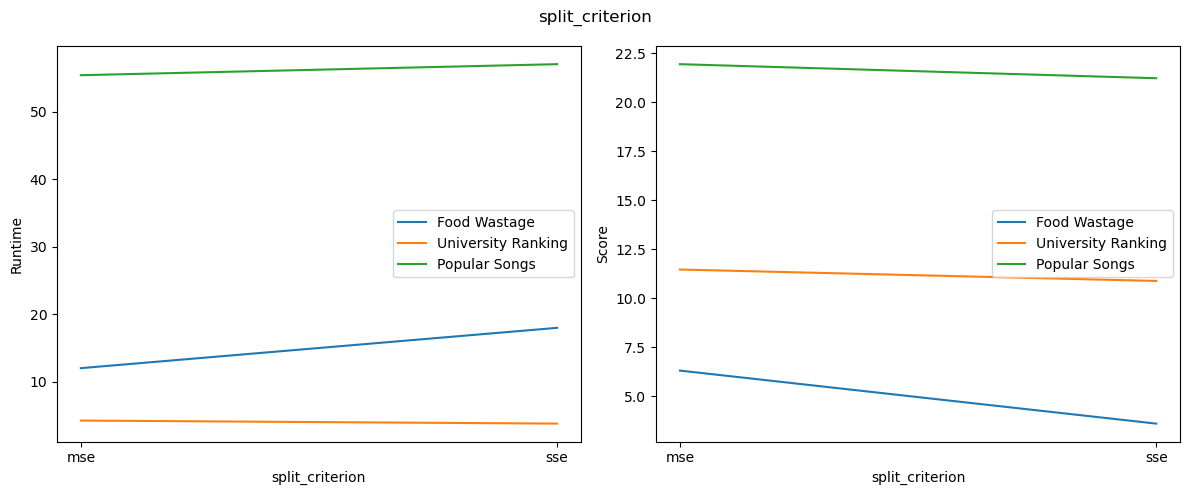

In [57]:
eval_param = {
    'min_samples_split': 8,
    'max_depth': 7,
    'split_criterion': 'sse'
}

parameter_eval.plot_parameter(train_results_food_waste, train_results_college_rank, train_results_popular_songs, param_grid, eval_param)

## Random Forest

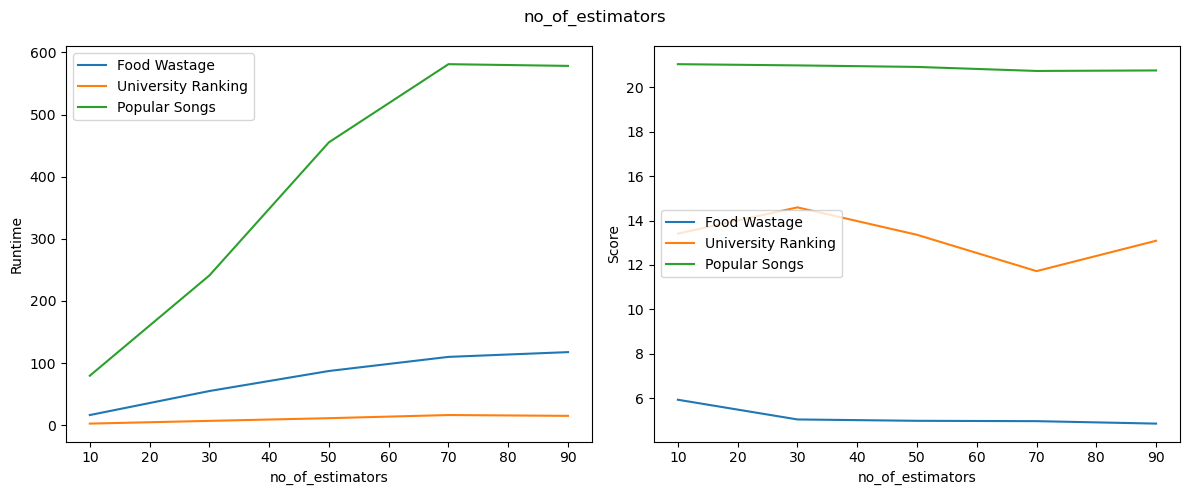

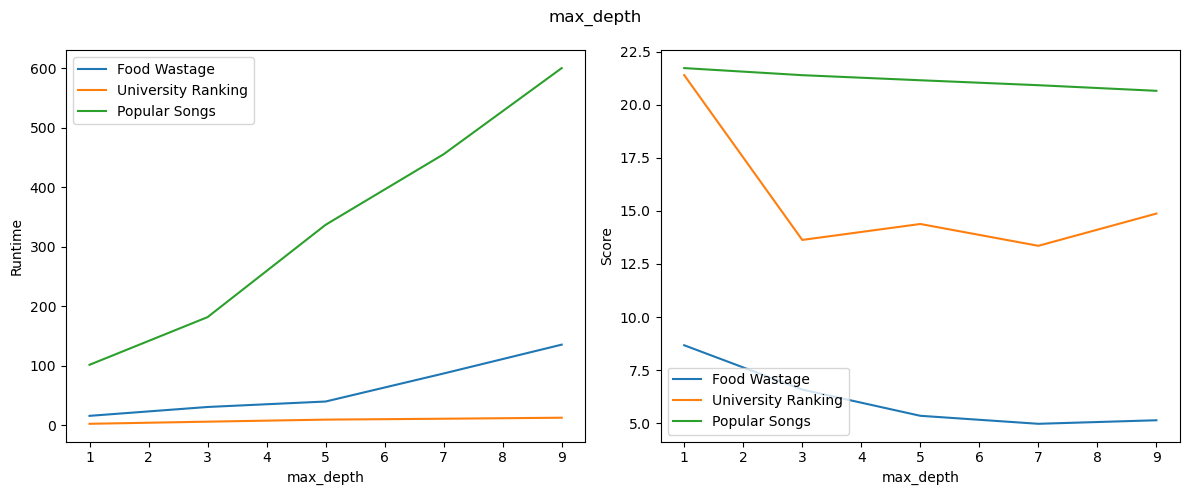

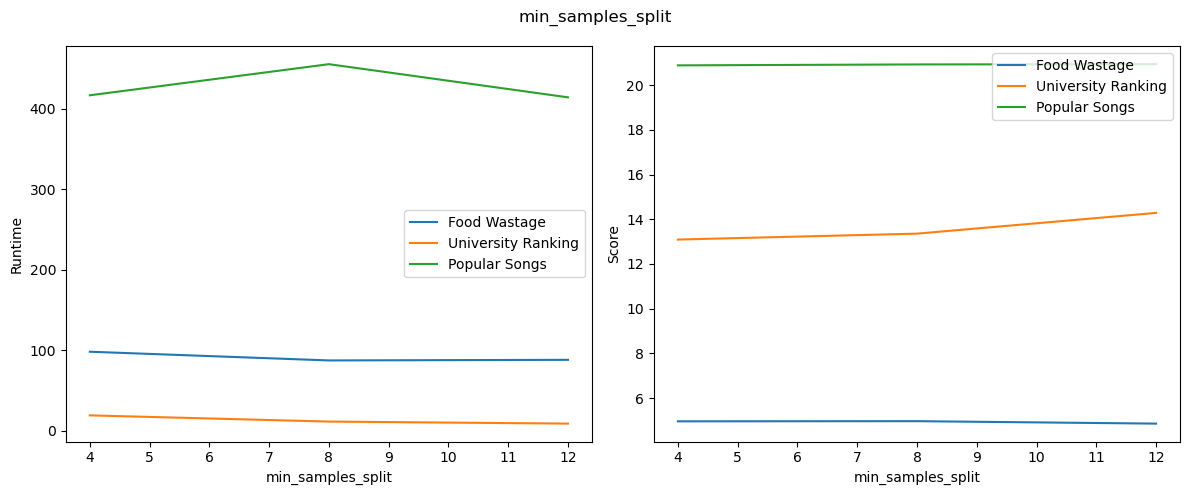

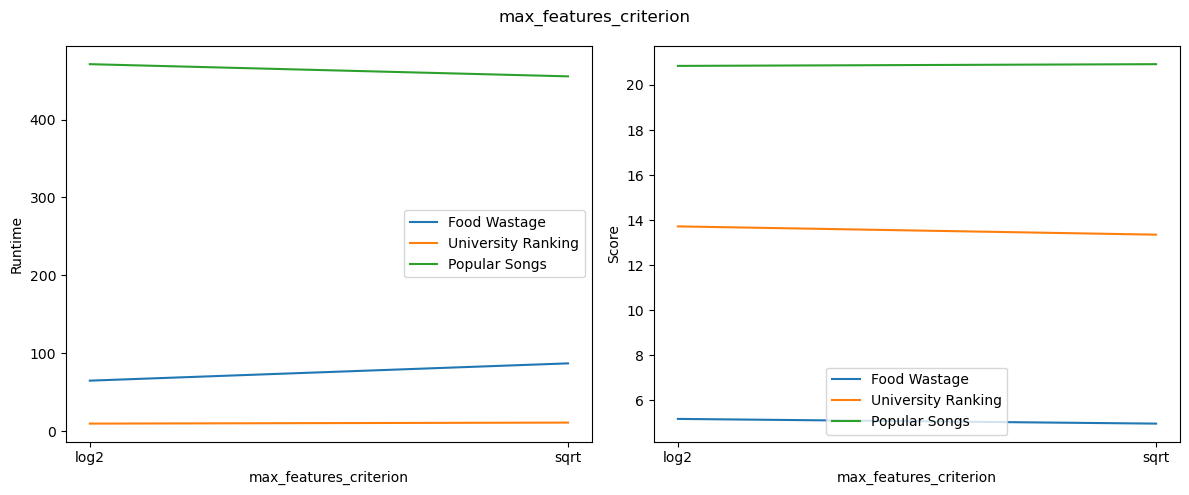

In [58]:
eval_param_rf = {
    'min_samples_split': 8,
    'max_depth': 7,
    'split_criterion': 'sse',
    'no_of_estimators': 50,
    'max_features_criterion': 'sqrt'
}

parameter_eval.plot_parameter(
    train_results_rf_food_waste, 
    train_results_rf_college_rank, 
    train_results_rf_popular_songs, 
    param_grid_rf, 
    eval_param_rf,
    rf = True
)

# Big Table

In [59]:
# TRAIN RESULTS
all_results = pd.concat([
    # Regression Tree
    train_results_food_waste.loc[[0]].assign(algorithm="Regression Tree", dataset="Food Wastage", implementation="Ours"),
    train_results_food_waste_scikit.loc[[0]].assign( algorithm="Regression Tree", dataset="Food Wastage", implementation="Scikit"),
    train_results_college_rank.loc[[0]].assign(algorithm="Regression Tree", dataset="University Rank", implementation="Ours"),
    train_results_college_rank_scikit.loc[[0]].assign( algorithm="Regression Tree", dataset="University Rank", implementation="Scikit"),
    train_results_popular_songs.loc[[0]].assign(algorithm="Regression Tree", dataset="Popular Songs", implementation="Ours"),
    train_results_popular_songs_scikit.loc[[0]].assign(algorithm="Regression Tree", dataset="Popular Songs", implementation="Scikit"),

    # Random Forest
    train_results_rf_food_waste.loc[[0]].assign(algorithm="Random Forest", dataset="Food Wastage", implementation="Ours"),
    train_results_rf_food_waste_scikit.loc[[0]].assign( algorithm="Random Forest", dataset="Food Wastage", implementation="Scikit"),
    train_results_rf_college_rank.loc[[0]].assign(algorithm="Random Forest", dataset="University Rank", implementation="Ours"),
    train_results_rf_college_rank_scikit.loc[[0]].assign( algorithm="Random Forest", dataset="University Rank", implementation="Scikit"),
    train_results_rf_popular_songs.loc[[0]].assign(algorithm="Random Forest", dataset="Popular Songs", implementation="Ours"),
    train_results_rf_popular_songs_scikit.loc[[0]].assign(algorithm="Random Forest", dataset="Popular Songs", implementation="Scikit")
    
]).reset_index(drop=True)
all_results = all_results.join(all_results['Parameters'].apply(pd.Series))

index_to_fix = ~all_results["criterion"].isna()
index_to_fix_as_well = ~all_results["n_estimators"].isna()

all_results.loc[index_to_fix, "split_criterion"] = all_results.loc[index_to_fix, "criterion"]
all_results.loc[index_to_fix_as_well, "no_of_estimators"] = all_results.loc[index_to_fix_as_well, "n_estimators"]

all_results = all_results.drop(["Parameters", "criterion"], axis=1)
all_results = all_results.rename(columns={'mean_rmse':'cross validated rmse', 'mean_mae': "cross validated mae"})


# PREDCTIONS
# Regression Tree
all_results = eval.big_table_formating(
    "Food Wastage", 
    all_results,
    
    food_waste_rmse_on_test_reg_tree,
    food_waste_mae_on_test_reg_tree,
    food_waste_rmse_on_test_reg_tree_scikit,
    food_waste_mae_on_test_reg_tree_scikit
)

all_results = eval.big_table_formating(
    "University Rank", 
    all_results,
    college_rank_rmse_on_test_reg_tree,
    college_rank_mae_on_test_reg_tree,
    college_rank_rmse_on_test_reg_tree_scikit,
    college_rank_mae_on_test_reg_tree_scikit
)
    
all_results = eval.big_table_formating(
    "Popular Songs", 
    all_results,
    popular_songs_rmse_reg_tree,
    popular_songs_mae_reg_tree,
    popular_songs_rmse_reg_tree_scikit,
    popular_songs_mae_reg_tree_scikit
)


# Random Forest
all_results = eval.big_table_formating(
    "Food Wastage", 
    all_results,
    food_waste_rmse_rf,
    food_waste_mae_rf,
    food_waste_rmse_rf_scikit,
    food_waste_mae_rf_scikit
    
)

all_results = eval.big_table_formating(
    "University Rank", 
    all_results,
    college_rank_rmse_rf,
    college_rank_mae_rf,
    college_rank_rmse_rf_scikit,
    college_rank_mae_rf_scikit,
)

all_results = eval.big_table_formating(
    "Popular Songs", 
    all_results,
    popular_songs_rmse_rf,
    popular_songs_mae_rf,
    popular_songs_rmse_rf_scikit,
    popular_songs_mae_rf_scikit,
)
all_results = pd.concat([all_results, pd.DataFrame([food_waste_knn_results, college_rank_knn_results, popular_songs_knn_results])], ignore_index=True)

all_results_reorderd = all_results[["algorithm", "dataset", "implementation", "runtime", "no_of_estimators", "min_samples_split", "max_depth", "split_criterion", "cross validated rmse", "cross validated mae", "test set rmse", "test set mae"]]

all_results_reorderd

,algorithm,dataset,implementation,runtime,no_of_estimators,min_samples_split,max_depth,split_criterion,cross validated rmse,cross validated mae,test set rmse,test set mae
0,Regression Tree,Food Wastage,Ours,28.508874,NaN,4.0,9.0,sse,3.588023,2.141455,3.871003,3.018660
1,Regression Tree,Food Wastage,Scikit,0.804412,NaN,14.0,9.0,squared_error,3.202585,1.939226,4.128377,3.198822
2,Regression Tree,University Rank,Ours,4.253196,NaN,4.0,5.0,mse,9.738025,7.783541,10.260182,7.983322
3,Regression Tree,University Rank,Scikit,0.694772,NaN,8.0,5.0,squared_error,9.962908,7.933744,10.567187,8.202730
4,Regression Tree,Popular Songs,Ours,83.641121,NaN,8.0,9.0,sse,21.160975,16.666737,19.847539,15.735736
5,Regression Tree,Popular Songs,Scikit,8.400170,NaN,16.0,7.0,squared_error,21.234650,16.837872,19.804346,15.746672
6,Random Forest,Food Wastage,Ours,155.022481,70.0,4.0,9.0,sse,4.319458,3.252234,3.871003,3.018660
7,Random Forest,Food Wastage,Scikit,0.139833,90.0,4.0,9.0,squared_error,4.229072,NaN,4.128377,3.198822
8,Random Forest,University Rank,Ours,22.928297,50.0,4.0,9.0,sse,10.969149,8.460529,10.260182,7.983322
9,Random Forest,University Rank,Scikit,0.025525,10.0,8.0,7.0,squared_error,10.217991,NaN,10.567187,8.202730
